<a href="https://colab.research.google.com/github/550tealeaves/DATA-70500-working-with-data/blob/main/Final_Four_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The 2026 Women's NCAA Championship game tips off TODAY at 3:30 PM ET on ABC. UCLA (36-1) faces South Carolina (36-3) in Phoenix. This week you'll use SQL aggregation to analyze both teams' tournament runs — and build a data-driven prediction for who wins tonight.

**GOALS**

Learn to summarize data the way an analyst does — using COUNT, AVG, SUM, GROUP BY, and HAVING. Then apply it to answer the biggest question in women's college basketball right now: who wins tonight?


In [1]:
# Dataset embedded directly in the code
import pandas as pd
import sqlite3

# ── TOURNAMENT GAME LOG ─────────────────────────────────────
# Real scores and stats from the 2026 Women's NCAA Tournament
games_data = [
  # team,           round,     opponent,        pts_for, pts_against, fg_pct, reb, ast, to, margin
  ('South Carolina','Round 64', 'Southern',       103, 34,  0.571, 52, 22, 10, 69),
  ('South Carolina','Round 32', 'USC',            101, 61,  0.548, 49, 20, 12, 40),
  ('Sweet 16',      'Sweet 16', 'Oklahoma',        94, 68,  0.512, 47, 18, 14, 26),
  ('South Carolina','Elite 8',  'TCU',             78, 52,  0.523, 51, 16, 11, 26),
  ('South Carolina','Final Four','UConn',          62, 48,  0.375, 47, 14, 8,  14),
  ('UCLA',          'Round 64', 'Cal Baptist',     96, 43,  0.583, 48, 24, 9,  53),
  ('UCLA',          'Round 32', 'Oklahoma State',  87, 68,  0.531, 44, 21, 13, 19),
  ('UCLA',          'Sweet 16', 'Minnesota',       80, 56,  0.518, 46, 19, 10, 24),
  ('UCLA',          'Elite 8',  'Duke',            70, 58,  0.497, 43, 17, 14, 12),
  ('UCLA',          'Final Four','Texas',          51, 44,  0.308, 41, 15, 23,  7),
]

games_cols = ['team','round','opponent','pts_for','pts_against',
              'fg_pct','rebounds','assists','turnovers','margin']
df_games = pd.DataFrame(games_data, columns=games_cols)
# Fix the Sweet 16 team name typo
df_games.loc[df_games['team']=='Sweet 16','team'] = 'South Carolina'

# ── PLAYER STATS ─────────────────────────────────────────────
# Season averages for key players in the championship matchup
players_data = [
  # team,           name,                pos, ppg,  rpg, apg,  fg_pct, ft_pct, mpg
  ('South Carolina','Joyce Edwards',      'F', 19.7, 7.2, 2.1,  0.582,  0.713, 30.2),
  ('South Carolina','Ta\'Niya Latson',   'G', 16.8, 5.1, 3.4,  0.441,  0.831, 31.5),
  ('South Carolina','Agot Makeer',        'F', 12.4, 4.8, 1.2,  0.498,  0.702, 24.1),
  ('South Carolina','Raven Johnson',      'G',  8.3, 3.9, 5.3,  0.412,  0.761, 29.8),
  ('South Carolina','Madina Okot',        'C',  9.1,10.8, 1.1,  0.541,  0.612, 27.3),
  ('UCLA',          'Lauren Betts',       'C', 17.2, 8.6, 1.8,  0.579,  0.675, 29.1),
  ('UCLA',          'Charlisse Leger-Walker','G',14.8,3.2,5.8,  0.431,  0.812, 32.0),
  ('UCLA',          'Kiki Rice',          'G', 13.1, 3.8, 4.2,  0.447,  0.798, 30.5),
  ('UCLA',          'Gianna Kneepkens',   'G', 11.9, 3.1, 2.8,  0.412,  0.741, 27.4),
  ('UCLA',          'Gabriela Jaquez',    'F', 10.3, 4.4, 2.3,  0.461,  0.689, 26.8),
]

players_cols = ['team','name','pos','ppg','rpg','apg','fg_pct','ft_pct','mpg']
df_players = pd.DataFrame(players_data, columns=players_cols)

# ── LOAD INTO SQLITE ─────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df_games.to_sql('tournament_games', conn, index=False, if_exists='replace')
df_players.to_sql('players', conn, index=False, if_exists='replace')

print('Tables loaded!')
print('tournament_games:', pd.read_sql_query('SELECT COUNT(*) FROM tournament_games',conn).iloc[0,0],'rows')
print('players:', pd.read_sql_query('SELECT COUNT(*) FROM players',conn).iloc[0,0],'rows')


Tables loaded!
tournament_games: 10 rows
players: 10 rows


##Preview both tables

In [12]:
# Look at the game log
print('--- TOURNAMENT GAMES ---') # will print label before the results
print(df_games)

# Look at the player stats
print('--- PLAYER STATS ---') # will print label before the results
print(df_players)

--- TOURNAMENT GAMES ---
             team       round        opponent  pts_for  pts_against  fg_pct  \
0  South Carolina    Round 64        Southern      103           34   0.571   
1  South Carolina    Round 32             USC      101           61   0.548   
2  South Carolina    Sweet 16        Oklahoma       94           68   0.512   
3  South Carolina     Elite 8             TCU       78           52   0.523   
4  South Carolina  Final Four           UConn       62           48   0.375   
5            UCLA    Round 64     Cal Baptist       96           43   0.583   
6            UCLA    Round 32  Oklahoma State       87           68   0.531   
7            UCLA    Sweet 16       Minnesota       80           56   0.518   
8            UCLA     Elite 8            Duke       70           58   0.497   
9            UCLA  Final Four           Texas       51           44   0.308   

   rebounds  assists  turnovers  margin  
0        52       22         10      69  
1        49       20 

## Download tables into csv

In [ ]:
# Convert to CSV & download
df_players.to_csv('df_players.csv', index=False)
df_games.to_csv('df_games.csv', index=False)
from google.colab import files
files.download('df_players.csv')
files.download('df_games.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New SQL Skills

| Function | Action | Example |
| :--- | :--- | :--- |
| **COUNT(*)** | Count # rows | # tournament games each team played |
| **SUM(col)** | Sum values in col | Total pts scored across tournament |
| **AVG(col)** | Avg values | Avg margin of victory per team |
| **MIN/MAX** | Lowest/highest value | Closest game (min margin) vs biggest blowout |
| **GROUP BY** | Split rows into groups before aggregating | Calculate stats separately for each team |
| **HAVING** | Filter groups after aggregating | Only show teams averaging 20+ pt margins |

-- **WHERE filters rows BEFORE grouping** (works on **individual rows**)

SELECT team, AVG(margin) as avg_margin <br>
FROM tournament_games<br>
WHERE pts_for > 60 <br>
GROUP BY team          
-- only include games where team scored 60+


-- **HAVING filters groups AFTER aggregating** (works on the **summary**)

SELECT team, AVG(margin) as avg_margin <br>
FROM tournament_games<br>
GROUP BY team <br>
HAVING AVG(margin) > 20     
-- only show teams with 20+ avg margin


## SQL + GROUP BY + COUNT
Using the tournament_games table, write a query that counts how many games each team played, their total points scored, and total points allowed. GROUP BY team.


In [8]:
pd.read_sql_query('''
    SELECT
      team, COUNT(*) AS num_games,
      SUM(pts_for) AS total_pts_scored,
      SUM(pts_against) AS total_pts_allowed
    FROM tournament_games
    GROUP BY team;
''', conn)

,team,num_games,total_pts_scored,total_pts_allowed
0,South Carolina,5,438,263
1,UCLA,5,384,269


## SQL + AVG + GROUP BY
Write a query showing each team's average points scored, average points allowed, and average margin of victory across the tournament. Which team has been more dominant?

In [6]:
pd.read_sql_query('''
    SELECT
      team,
      AVG(pts_for) AS average_pts_scored,
      AVG(pts_against) AS average_pts_allowed
    FROM tournament_games
    GROUP BY team;
''', conn)

,team,average_pts_scored,average_pts_allowed
0,South Carolina,87.6,52.6
1,UCLA,76.8,53.8


## SQL + MIN / MAX
Find each team's biggest blowout win (MAX margin) and their closest game (MIN margin). What does this tell you about each team's floor and ceiling?

In [7]:
pd.read_sql_query('''
    SELECT
      team,MAX(margin), MIN(margin)
    FROM tournament_games
    GROUP BY team;
''', conn)

,team,MAX(margin),MIN(margin)
0,South Carolina,69,14
1,UCLA,53,7


## SQL + HAVING
Write a query that shows only rounds where a team won by MORE than 20 points. Use HAVING to filter after grouping. How many such games did each team have?

In [ ]:
# Misses the SC vs TCU game that also had a margin of 26
pd.read_sql_query('''
    SELECT *
    FROM tournament_games
    GROUP BY margin
    HAVING margin > 20
    ORDER BY team ASC;
''', conn)

,team,round,opponent,pts_for,pts_against,fg_pct,rebounds,assists,turnovers,margin
0,South Carolina,Sweet 16,Oklahoma,94,68,0.512,47,18,14,26
1,South Carolina,Round 32,USC,101,61,0.548,49,20,12,40
2,South Carolina,Round 64,Southern,103,34,0.571,52,22,10,69
3,UCLA,Sweet 16,Minnesota,80,56,0.518,46,19,10,24
4,UCLA,Round 64,Cal Baptist,96,43,0.583,48,24,9,53


## SQL + AVG + WHERE
South Carolina's toughest game was the Final Four against UConn — they shot just 37.5%. Write a query using WHERE to exclude that game, then recalculate their average FG%. How much does one bad shooting game affect their tournament average?

In [ ]:
pd.read_sql_query('''
    SELECT team, AVG(fg_pct) AS avg_fg_percentage
    FROM tournament_games
    WHERE team = 'South Carolina' AND fg_pct != 0.375;
''', conn)

,team,avg_fg_percentage
0,South Carolina,0.5385


## Python + player stats
Switch to the players table. Using Python, group by team and calculate: average PPG, average RPG, average FG%. Which team has the higher-scoring roster on paper?
<br>



*   UCLA is the higher scoring team based on a slightly higher average points per game, but South Carolina does not trail too far behind.
*   But South Carolina has a higher average rebound per game and average field goal percentage



In [17]:
import matplotlib.pyplot as plt
import numpy as np


# Load dataset (make sure the file path is correct)
# df = pd.read_csv("ncaaw_players.csv")

# Use df_players directly
# df_group = pd.DataFrame(df_players) # df_group is not strictly needed here

# Preview columns (optional, helps confirm names)
print(df_players.columns)

# Group by Team and calculate averages
team_stats = (
    df_players.groupby("team") # Use 'team' column for grouping
      .agg({
          "ppg": "mean", # Use 'ppg' for points per game
          "rpg": "mean", # Use 'rpg' for rebounds per game
          "fg_pct": "mean" # Use 'fg_pct' for field goal percentage
      })
      .reset_index()
)

# Rename columns for clarity
team_stats.rename(columns={
    "ppg": "Avg_PPG",
    "rpg": "Avg_RPG",
    "fg_pct": "Avg_FG%"
}, inplace=True)

# Optional: round values
team_stats = team_stats.round({
    "Avg_PPG": 2,
    "Avg_RPG": 2,
    "Avg_FG%": 3
})

# Display results
print('---Comparison of teams---')
print(team_stats)


Index(['team', 'name', 'pos', 'ppg', 'rpg', 'apg', 'fg_pct', 'ft_pct', 'mpg'], dtype='object')
---Comparison of teams---
             team  Avg_PPG  Avg_RPG  Avg_FG%
0  South Carolina    13.26     6.36    0.495
1            UCLA    13.46     4.62    0.466


## Visualization
- Plotted line charts on player stats

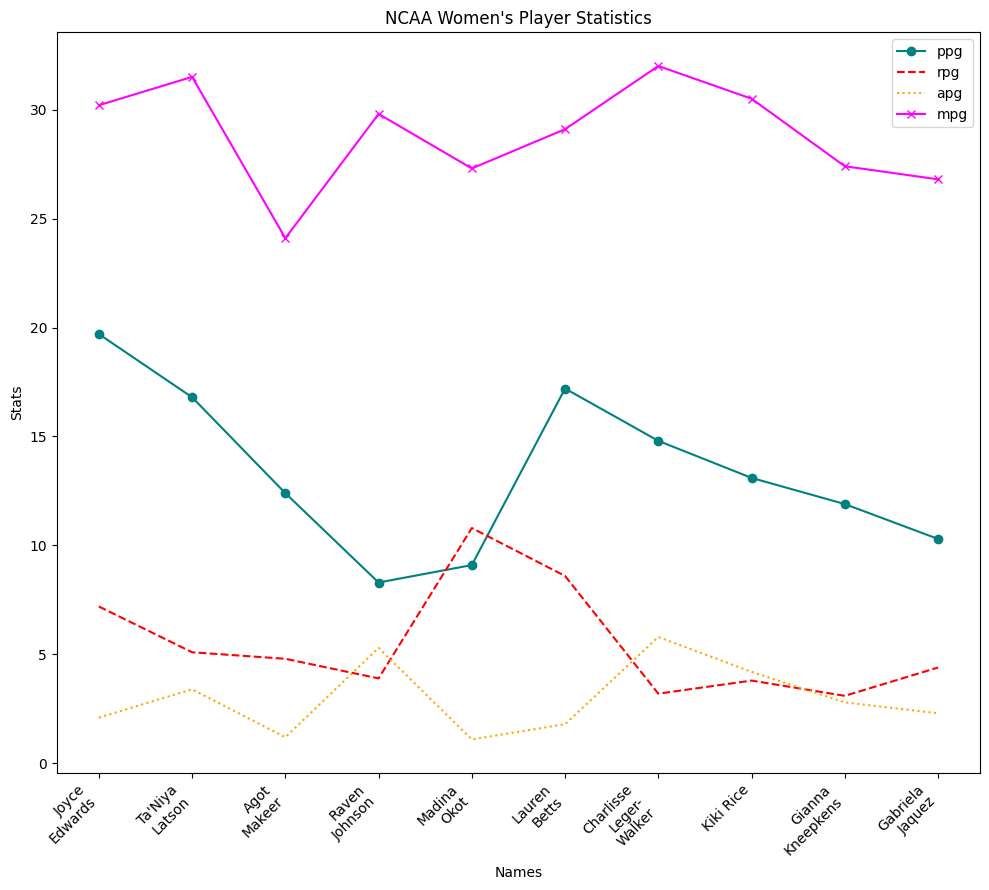

In [41]:
import textwrap
# print(df_players.columns)

plt.figure(figsize=(10, 9))  # 10 inches wide, 6 inches high

x = df_players['name']
y1 = df_players['ppg']
y2 = df_players['rpg']
y3 = df_players['apg']
y4 = df_players['mpg']

# Plot each line
plt.plot(x, y1, label='ppg', color='teal', marker='o')
plt.plot(x, y2, label='rpg', color='red', linestyle='--')
plt.plot(x, y3, label='apg', color='orange', linestyle=':')
plt.plot(x, y4, label='mpg', color='magenta', marker='x')

# Use textwrap.fill to insert newlines at a specific width
wrapped_names = [textwrap.fill(name, width=10) for name in x]

# Add labels and legend
plt.xlabel('Names')
plt.ylabel('Stats')
plt.title("NCAA Women's Player Statistics")
plt.legend() # Displays the labels

# Set x-axis tick labels and rotate them for better readability
plt.xticks(x, wrapped_names, rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


## Predict + Reflect
Based on everything you've found in tasks 1–6, write your prediction for tonight's game. Which team wins and why? Back it up with at least 3 specific numbers from your queries. Write it in 3–4 sentences like you're an analyst making a pre-game report


*   I think South Carolina wins because they have a greater margin of victory than UCLA, beating 4 out of 5 teams with a margin greater than 20 points.
*   They also had fewer turnovers than UCLA, which meant fewer free points to the opposition. (55 vs 69)
*   Lastly, they had overall higher field goal percentage than UCLA (0.51 vs 0.49)



